In [2]:
# 길이, 무게 리스트 생성

fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [41]:
# 길이, 무게 데이터를 2차원 리스트로 합쳐주고, 타깃 리스트 생성

fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target=[1]*35+[0]*14

In [42]:
# 입력 리스트, 타깃 리스트 확인

print(fish_data)
print(fish_target)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [45]:
# 사이킷런을 활용해 knn 모델 생성

from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

In [44]:
# 훈련 세트와 테스트 세트 나누기

train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]

In [46]:
# 훈련 시키고 테스트 해보기

kn.fit(train_input, train_target)
kn.score(test_input, test_target)

0.0

In [47]:
# 데이터를 섞기 위해 넘파이 도입

import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [57]:
# 넘파이를 이용해 데이터 섞기

# seed를 42로 설정
np.random.seed(42)
# 번호 나열하고
index = np.arange(49)
# 섞기
np.random.shuffle(index)

In [56]:
# 잘 섞였나 확인

print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [55]:
# 섞은 index로 다시 훈련 세트 생성

train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

In [54]:
# 나머지 index로 테스트 세트 생성

test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

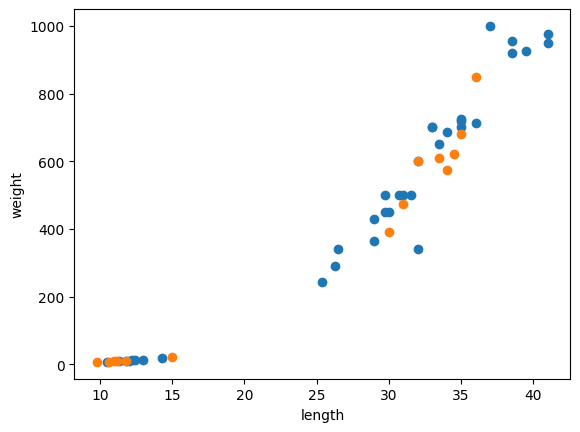

In [58]:
# 산점도 그래프로 잘 섞였는지 시각적으로 확인

import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(test_input[:,0], test_input[:,1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [52]:
# 훈련하고 테스트 해보기

kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [51]:
# 이번엔 사이킷런 라이브러리를 사용해보자

fish_data = np.column_stack((fish_length,fish_weight))
print(fish_data[:5])

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


In [50]:
# 타깃 배열 생성

fish_target = np.concatenate((np.ones(35), np.zeros(14)))
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [49]:
# 사이킷런을 사용해 테스트 세트와 훈련 세트 분리

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

In [60]:
# 잘 됐나 확인

print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(35, 2) (14, 2)
(35,) (14,)


In [61]:
# 도미와 빙어가 10:3 = 3.3 : 1로 나뉨

print(test_target)

[0 0 1 0 1 1 1 0 1 1 0 1 1 0]


In [62]:
# fish_target에 strarify를 붙여 타깃 비율에 맞춰 데이터를 나누도록 설정

train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

In [64]:
# 다시 출력해 확인 9:4 = 2.25:1로 나뉨

print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [63]:
# knn 알고리즘으로 모델 평가해보기

from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [66]:
# 새 데이터 예측해보기 - 예상과 다름

print(kn.predict([[25, 150]]))

[0.]


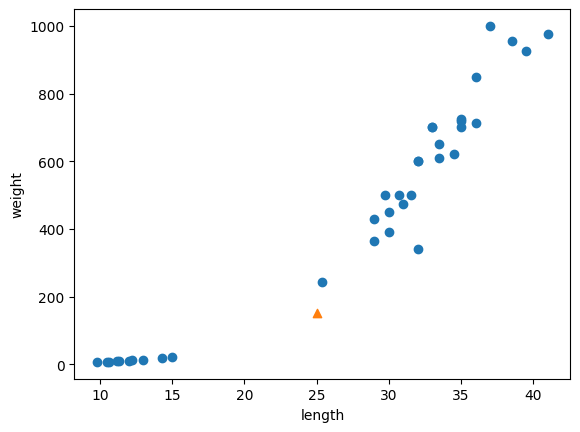

In [67]:
# 산점도 그래프에 새 데이터 찍어보기

import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [68]:
# 새 데이터와 가까운 데이터들의 정보를 담은 배열 생성

distances, indexes = kn.kneighbors([[25, 150]])

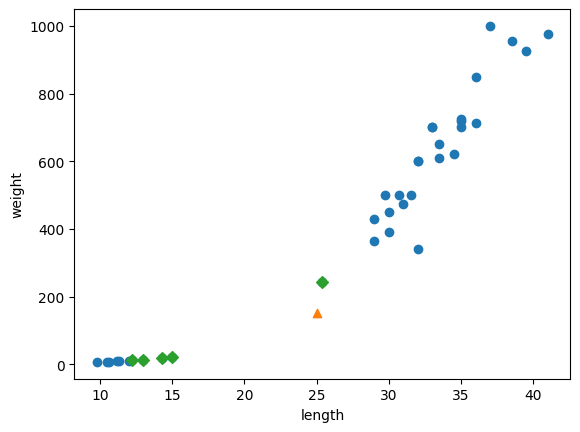

In [69]:
# 가까운 데이터들 산점도 그래프에서 확인하기

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [70]:
# 가까운 데이터들 좌표와 거리 확인하기

print(train_input[indexes])
print(train_target[indexes])
print(distances)

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]
[[1. 0. 0. 0. 0.]]
[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


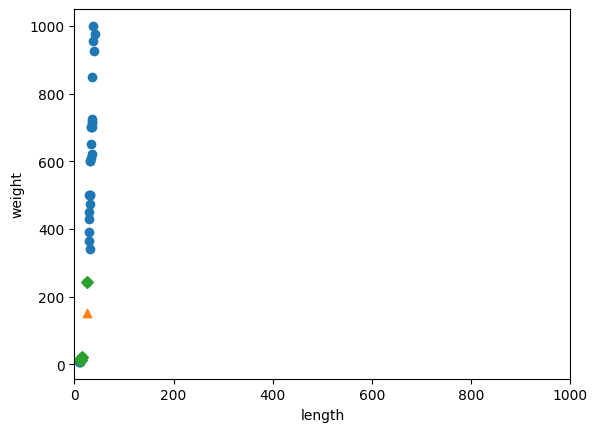

In [71]:
# x축과 y축 스케일 맞춰서 다시 산점도 그래프 그려보기

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlim((0, 1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [72]:
# 넘파이를 이용햏 훈련세트의 평균과 표준편차 구하기

mean=np.mean(train_input, axis=0)
std=np.std(train_input, axis=0)
print(mean, std)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [73]:
# 표준 점수 구하기

train_scaled=(train_input-mean)/std

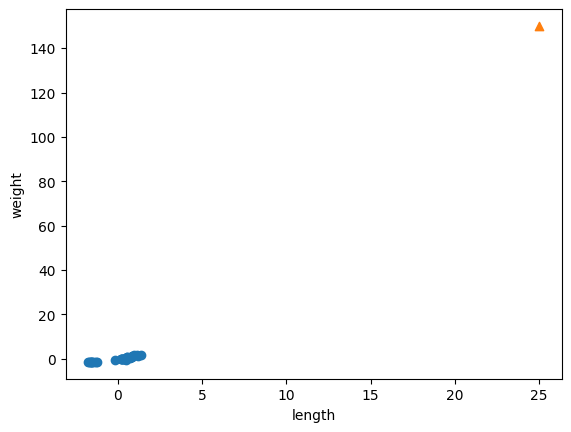

In [74]:
# 산점도 그래프 다시 그리기

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

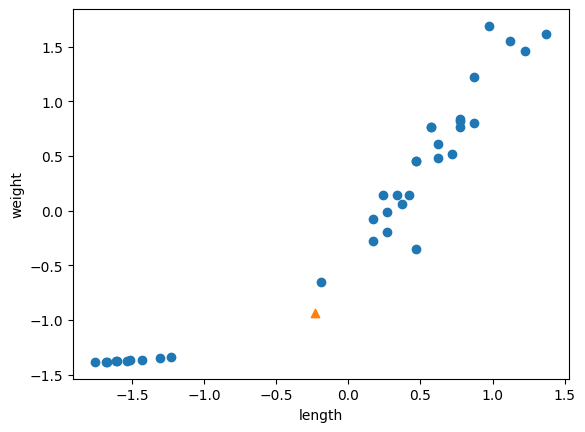

In [75]:
# 새 데이터도 표준 점수 구해서 다시 산점도 그래프 그리기

new=([25,150]-mean)/std
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [77]:
# 모델 다시 훈련시키기

kn.fit(train_scaled,train_target)
test_scaled=(test_input-mean)/std
kn.score(test_scaled, test_target)
print(kn.predict([new]))

[1.]


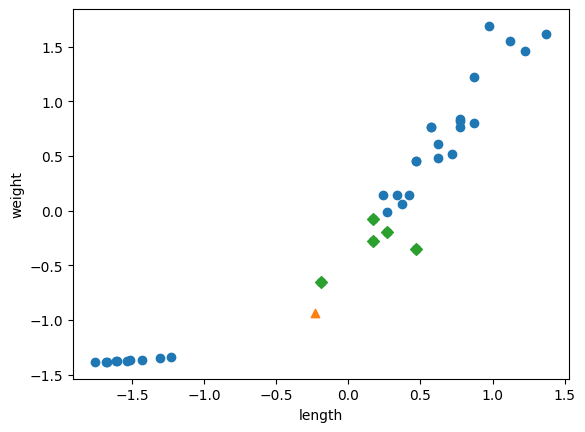

In [78]:
# 최근접 5개 이웃 산점도 그래프에 표시하기

distances,indexes=kn.kneighbors([new])
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0],new[1],marker='^')
plt.scatter(train_scaled[indexes,0],train_scaled[indexes,1],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [3]:
# 과제 1 - 원하는 비율로 전체 훈련 데이터를 분리하고 KNN 알고리즘 정확도 테스트하기

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import numpy as np
fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [7]:
# Q1. 훈련 세트 : 테스트 세트 = 7 : 3로 데이터 분리하기

train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(fish_data, fish_target, test_size=0.3, random_state=42)

In [8]:
# Q2. 훈련 세트 : 테스트 세트 = 5 : 5로 데이터 분리하기

train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(fish_data, fish_target, test_size=0.5, random_state=42)

In [9]:
# Q3. 훈련 세트 : 테스트 세트 = 9 : 1로 데이터 분리하기

train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(fish_data, fish_target, test_size=0.1, random_state=42)

In [19]:
# Q4. Q1, Q2, Q3 훈련 세트와 테스트 세트의 샘플 개수 확인해보고, KNN 알고리즘 정확도 테스트해보기

print("[7:3 비율] 훈련 세트 : ", len(train_target_7), "개, 테스트 세트 : ", len(test_target_7), "개")
kn7 = KNeighborsClassifier()
kn7.fit(train_input_7, train_target_7)
print("[7:3 비율] 정확도 : ", kn7.score(test_input_7, test_target_7))

print("[5:5 비율] 훈련 세트 : ", len(train_target_5), "개, 테스트 세트 : ", len(test_target_5), "개")
kn5 = KNeighborsClassifier()
kn5.fit(train_input_5, train_target_5)
print("[5:5 비율] 정확도 : ", kn5.score(test_input_5, test_target_5))

print("[9:1 비율] 훈련 세트 : ", len(train_target_9), "개, 테스트 세트 : ", len(test_target_9), "개")
kn9 = KNeighborsClassifier()
kn9.fit(train_input_9, train_target_9)
print("[9:1 비율] 정확도 : ", kn9.score(test_input_9, test_target_9))

[7:3 비율] 훈련 세트 :  34 개, 테스트 세트 :  15 개
[7:3 비율] 정확도 :  1.0
[5:5 비율] 훈련 세트 :  24 개, 테스트 세트 :  25 개
[5:5 비율] 정확도 :  1.0
[9:1 비율] 훈련 세트 :  44 개, 테스트 세트 :  5 개
[9:1 비율] 정확도 :  1.0


In [22]:
# 과제 2 - numpy 사용하지 않고 직접 평균과 표준편차 구하기

lengths = [fish[0] for fish in train_input_7]
weights = [fish[1] for fish in train_input_7]
n = len(train_input_7)


In [25]:
# Q1.  sum() 함수를 이용해 길이와 무게의 평균을 구하기

mean_length = sum(lengths) / len(lengths)
mean_weight = sum(weights) / len(weights)
print(mean_length, mean_weight)

25.97941176470588 418.77058823529416


In [34]:
# Q2. for문과 **연산자를 이용해 길이와 무게의 분산을 구하기

var_length = 0
for i in lengths : var_length += (i-mean_length) **2 / len(lengths)
print(var_length)

var_weight = 0
for i in weights : var_weight += (i-mean_weight) **2 / len(weights)
print(var_weight)



109.68869377162632
109444.24913494811


In [36]:
# Q3. 분산에 제곱근을 씌워 표준편차 구하기
std_length = var_length ** 0.5
std_weight = var_weight ** 0.5

print(std_length)
print(std_weight)

10.473237024512828
330.8235921680135


In [41]:
# Q4. 구해진 평균과 표준편차를 이용해 train_input의 모든 데이터를 스케일링하여 새로운 리스트에 담기

train_scaled_manual = []
for fish in train_input_7:
    # 코드를 작성하세요 ( append 활용 )
    train_scaled_manual.append([(fish[0]-mean_length)/std_length,(fish[1]-mean_weight)/std_weight])

# 확인용 평균과 표준편차 출력
print(f"수동 계산 평균: {mean_length:.2f}, {mean_weight:.2f}")
print(f"수동 계산 표준편차: {std_length:.2f}, {std_weight:.2f}")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")


수동 계산 평균: 25.98, 418.77
수동 계산 표준편차: 10.47, 330.82
스케일링된 첫 데이터: [np.float64(0.35524721025467154), np.float64(0.24553693777514007)]


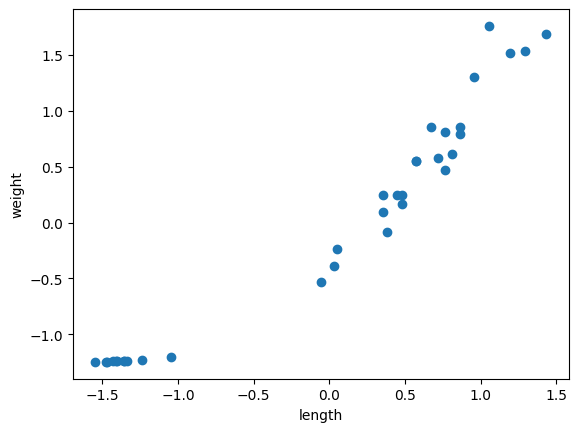

In [48]:
# 과제 3 - 산점도 그래프 그리기

import matplotlib.pyplot as plt

# 1. 스케일링된 2차원 리스트에서 길이(X축)와 무게(Y축) 데이터 분리하기


scaled_lengths = [row[0] for row in train_scaled_manual]
scaled_weights = [row[1] for row in train_scaled_manual]

# 2. 산점도 그리기

plt.scatter(scaled_lengths,scaled_weights)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()